In [2]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt

import scipy as sp
import scipy.linalg
import scipy.optimize

# from scipy import optimize

import glob

# # import lsqfit
# from lib import Jackknife
# from lib import simple_mean
# from lib import format_print

# plt.rcParams['figure.dpi'] = 300

In [3]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    'font.size'  : 20
})

In [4]:
def f(t, nmax, T):
    res = 0.0
    for n in range(1,nmax):
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*t )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(T-t) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(t+T) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(2*T-t) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(t+2*T) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(3*T-t) )
    return res/(8.0*np.pi)

In [5]:
gsq=0.050000
beta=1.0/gsq

In [14]:
"prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat"

'prop_gauge_gsq0.050000_L1_Nt120_T12.000000.dat'

In [6]:
T=12
Nt=120

In [7]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

In [15]:
l1_1

array([9.74351e-02, 7.37442e-02, 5.60855e-02, 4.28708e-02, 3.29405e-02,
       2.54455e-02, 1.97628e-02, 1.54339e-02, 1.21200e-02, 9.57048e-03,
       7.59896e-03, 6.06645e-03, 4.86893e-03, 3.92824e-03, 3.18538e-03,
       2.59569e-03, 2.12514e-03, 1.74775e-03, 1.44358e-03, 1.19721e-03,
       9.96738e-04, 8.32862e-04, 6.98317e-04, 5.87393e-04, 4.95576e-04,
       4.19288e-04, 3.55674e-04, 3.02448e-04, 2.57770e-04, 2.20156e-04,
       1.88398e-04, 1.61514e-04, 1.38701e-04, 1.19296e-04, 1.02757e-04,
       8.86314e-05, 7.65461e-05, 6.61892e-05, 5.73003e-05, 4.96611e-05,
       4.30882e-05, 3.74272e-05, 3.25476e-05, 2.83391e-05, 2.47079e-05,
       2.15747e-05, 1.88720e-05, 1.65422e-05, 1.45365e-05, 1.28131e-05,
       1.13368e-05, 1.00775e-05, 9.00987e-06, 8.11246e-06, 7.36750e-06,
       6.76026e-06, 6.27881e-06, 5.91374e-06, 5.65793e-06, 5.50641e-06,
       5.45622e-06, 5.50641e-06, 5.65793e-06, 5.91374e-06, 6.27881e-06,
       6.76026e-06, 7.36750e-06, 8.11246e-06, 9.00987e-06, 1.007

In [16]:
beta

20.0

In [10]:
xx=T * np.arange(10*Nt)/(10*Nt)
yy= f(xx, 4000, T) # *fixme*

tosave = np.array(
    [xx, yy]
).T

In [11]:
tosave

array([[0.00000000e+00, 1.69765266e+09],
       [1.00000000e-02, 1.59154933e+05],
       [2.00000000e-02, 1.98943574e+04],
       ...,
       [1.19700000e+01, 5.89461705e+03],
       [1.19800000e+01, 1.98943574e+04],
       [1.19900000e+01, 1.59154933e+05]])

In [13]:
np.savetxt('gauge_exact.dat', tosave)

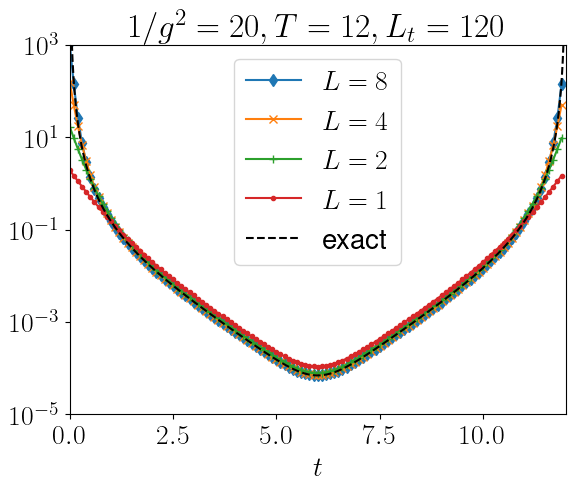

In [11]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, beta*l8_1, label="$L=8$", marker='d' )
plt.plot( xx, beta*l4_1, label="$L=4$", marker='x' )
plt.plot( xx, beta*l2_1, label="$L=2$", marker='+' )
plt.plot( xx, beta*l1_1, label="$L=1$", marker='.' )
# plt.plot( xx, l12_1, label="$L=16$" )

xx=T * np.arange(10*Nt)/(10*Nt)

yy= f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, T=12, L_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-5, 1.0e3)
plt.legend()

plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [12]:
def Gt( t, nmax, T ):
    res = 0.0
    for n in range(nmax+1):
        res += np.sqrt(n*(n+1.0))*(2.0*n+1.0) * ( np.exp( -np.sqrt( n*(n+1.0) )*t ) + np.exp( -np.sqrt( n*(n+1.0) )*(T-t) ) )
    res /= 4.0*np.pi
    return res

In [13]:
ts=T*np.arange(100)/100
Gts = np.array([Gt( t, 10, T ) for t in ts])

In [14]:
def fitter( t, z ):
    return np.log( z * Gt(t, nmax, T) )

In [15]:
xx=T * np.arange(Nt)/Nt

In [16]:
xx

array([ 0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,
        1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,
        2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,
        3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,
        4.4,  4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,  5.3,  5.4,
        5.5,  5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,  6.4,  6.5,
        6.6,  6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,  7.5,  7.6,
        7.7,  7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,  8.6,  8.7,
        8.8,  8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,
        9.9, 10. , 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 10.8, 10.9,
       11. , 11.1, 11.2, 11.3, 11.4, 11.5, 11.6, 11.7, 11.8, 11.9])

In [25]:
yy = l1_1

In [26]:
for nmax in np.arange(2, 200):
    opt = sp.optimize.curve_fit( fitter, xx, np.log(beta*yy), full_output=True, absolute_sigma=True, p0=1 )
    diff = np.sum( opt[2]['fvec']**2 )
    print(nmax, diff/(yy.shape[0]-2), [opt[0][0], np.sqrt(opt[1][0,0])])

2 0.03435198259463043 [0.7885772419902148, 0.07198691315655113]
3 0.003133953418892553 [0.6926172771988411, 0.06322701887966208]
4 0.03961911933982975 [0.643084177611163, 0.05870528559673144]
5 0.09734932602718786 [0.6126510695029564, 0.05592713505370569]
6 0.16037908680690693 [0.5919993440185425, 0.054041898434892204]
7 0.22267658642790245 [0.5770442577935414, 0.0526766896336683]
8 0.28194219747501836 [0.5657037447087168, 0.051641444513401615]
9 0.33740747499072676 [0.5568024304379463, 0.05082886497810804]
10 0.38895858543950224 [0.5496256276816753, 0.0501737093722282]
11 0.43676009642597813 [0.5437134244312358, 0.04963399458460972]
12 0.48108569809606094 [0.538756291341205, 0.04918146363026284]
13 0.5222403102139996 [0.5345381986865411, 0.04879639678747002]
14 0.5605244810077661 [0.5309037521904196, 0.04846460866896601]
15 0.5962189660263358 [0.5277383038049551, 0.04817563330020444]
16 0.6295790745362023 [0.5249554020350563, 0.04792157835300515]
17 0.6608337164720548 [0.5224886250827